# Simulation of GBS Non-Gaussian State Generation and Its GKP-Like Structure

This notebook studies **conditional optical state preparation** with the MrMustard simulator.
We model linear-optical circuits with squeezed-vacuum inputs, beam splitters, and photon-number heralding to generate non-Gaussian output states.

The motivation is twofold:
- test a numerically accessible route to non-Gaussian-state generation [1], and
- quantify how closely the generated states resemble GKP grids using nonlinear GKP squeezing ideas [2].

## What Is Done in This Notebook

1. Validate the basic heralding mechanism for a non-Gaussian state construction.
2. Reach grid like output state

To implement:

3. Find optimal resembling GKP state (squeezing $r_{GKP}$ and rescaling $s$)
4. Get Nonlinear GKP squeezing parameter

...

## Scope

This is a **simulation study** intended for reproducible exploration and parameter screening.
It does not include experimental imperfections (loss, detector dark counts, mode mismatch) and therefore should be interpreted as an idealized baseline.

## References

[1] Xanadu paper

[2] P. Marek, "Ground State Nature and Nonlinear Squeezing of Gottesman-Kitaev-Preskill States," *Physical Review Letters* **132**, 210601 (2024). https://doi.org/10.1103/PhysRevLett.132.210601

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mrmustard.physics.wigner import wigner_discretized

from IPython.display import display

from circuits_mrmustard import show_state_wigner, circuit_3mode_GBS_original, circuit_3mode_GBS, circuit_Nmode_GBS, compare_Wigners

from GKP_States import GKPState
from Gaussian_Gates_Symplectic import *

# Define Wigner functions grid
q_min, q_max = -5, 5
N_points = 501

# To Be Implemented

/home/lcgho/non-gaussian-state-simulations/simulations/lib/python3.13/site-packages/mrmustard/physics/ansatz/array_ansatz.py:260: UserWarning: The fock array is being padded with zeros. Is this really necessary?
  warn(


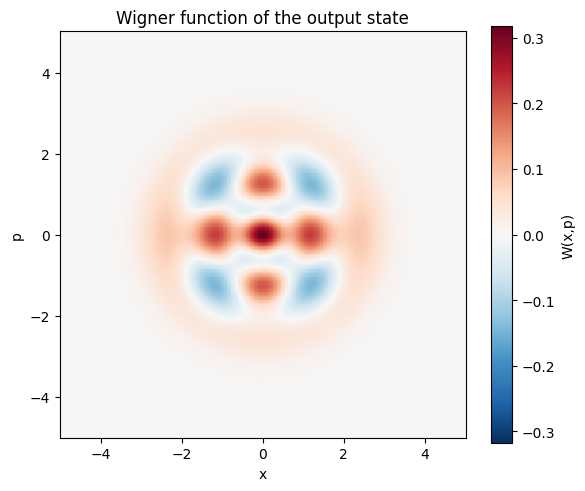

Probability of the state:  0.015234182096094128


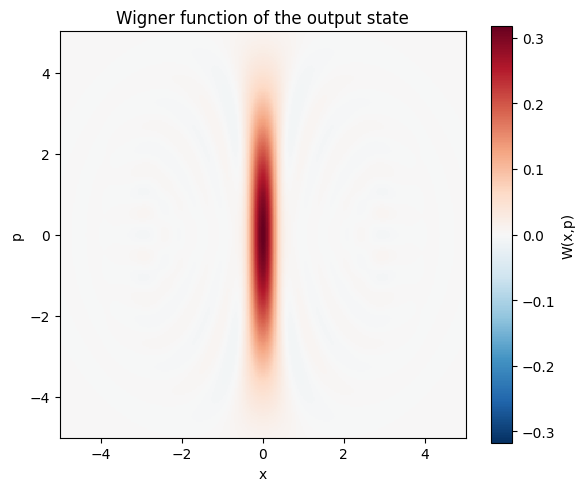

Probability of the state:  0.03684539448765053


In [2]:
N_meas = [2, 2]
r_dB = 10
# From Ze-Yan's file in TN_Sampling/Beework2.0_example.ipynb
theta_21, phi_21 = np.pi/4, 0
theta_10, phi_10 = np.pi/6, 0
state1, probability1 = circuit_3mode_GBS_original(Ns = N_meas, r0 = r_dB, theta10 = theta_10, theta21=theta_21, cutoff=20, r_in_dB=True)

Wigner1 = wigner_discretized(
    state1.dm().ansatz.array,
    np.linspace(q_min, q_max, N_points),
    np.linspace(q_min, q_max, N_points),
)

#display(state1)
show_state_wigner(state1, title="Wigner function of the output state")

print("Probability of the state: ", probability1)

# BS_{10}(pi/6,0) corresponds to BS_{01}(pi/6,pi)
# BS_{21}(pi/4,0) corresponds to BS_{12}(pi/4,pi)
phi_0 = np.pi
phi_1 = 1.5 *np.pi

state, probability = circuit_3mode_GBS(Ns = N_meas, r0 = r_dB, theta0 = theta_21, theta1=theta_10, phi0=phi_0, phi1=phi_1, cutoff=20, r_in_dB=True)

#display(state)
show_state_wigner(state, title="Wigner function of the output state")

print("Probability of the state: ", probability)

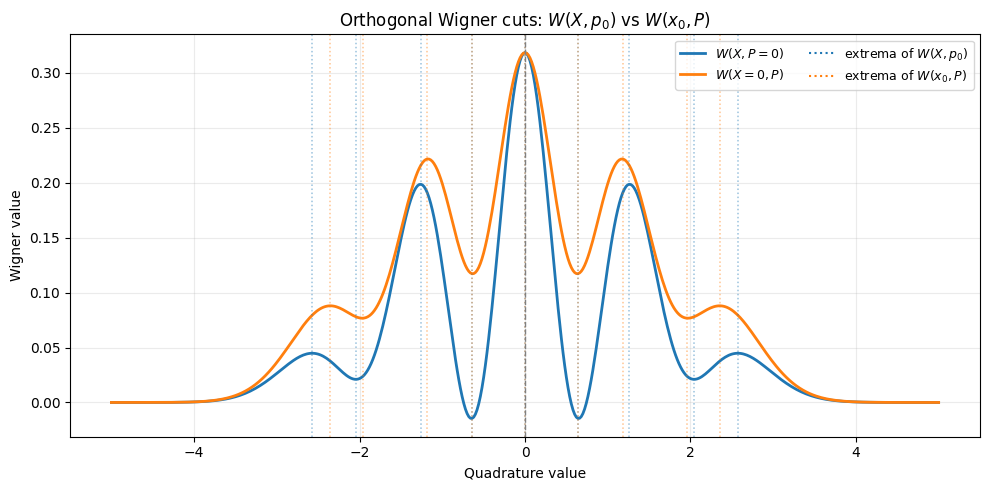

{'x_step': 0.019999999999999574, 'p_step': 0.019999999999999574, 'x_cut_actual': 0.0, 'p_cut_actual': 0.0, 'n_max_x_cut': 5, 'n_min_x_cut': 4, 'n_max_p_cut': 5, 'n_min_p_cut': 4, 'maxima_alignment_mean': 0.12000000000000002, 'maxima_alignment_max': 0.2200000000000002, 'minima_alignment_mean': 0.040000000000000036, 'minima_alignment_max': 0.08000000000000007}


In [3]:
from circuits_mrmustard import plot_wigner_orthogonal_cuts

result = plot_wigner_orthogonal_cuts(
    Wigner1,
    x_cut=0.0,
    p_cut=0.0,
    prominence_frac=0.02,
    min_separation_pts=8,
    extrema_colors=("tab:blue", "tab:orange"),
    extrema_linestyle=":",
)

print(result["diagnostics"])

## 3) GKP interpretation and scale fitting

This section tests how well the selected non-gaussian outcome state can be interpreted as a **rectangular finite-energy GKP-like state** with a rescaled lattice constant [2].

### Why this comparison is useful
The non-gaussian Wigner function shows a grid-like interference structure.  
A quantitative way to test this resemblance is to evaluate the nonlinear GKP-squeezing objective $\xi(s)$ [2] and find the lattice scale that minimizes it.

### Criterion quantifying GKP-ness (for a given grid) of the state
For lattice vectors $v_1,v_2$, displacement $d$, and scale $l$, define
$$
\mathit{Q}_{l,v_1,v_2,d}(\hat r)=2-\cos\!\left(\tfrac{1}{2}l\,[\omega(\hat r,v_1)+\omega(d,v_1)]\right)-\cos\!\left(l\,[\omega(\hat r,v_2)+\omega(d,v_2)]\right),
$$
with symplectic form $\omega(x,y)=x^T\Omega y$.

The nonlinear GKP-squeezing for this grid is defined as
$$
\xi_{l,v_1,v_2,d}=\langle\mathit{Q}_{l,v_1,v_2,d}(\hat r)\rangle,
$$
where smaller values indicate better consistency with the chosen grid.

### GKP state resembling the state
For comparison we consider the squeezed $|0\rangle_{\mathrm{L}}$ GKP state, with
$$
v_1=(1,0)^T,\qquad v_2=(0,1)^T,\qquad d=(0,0)^T.
$$
Its canonical qubit lattice scale is
$$
l_{\mathrm{qubit}}=2\sqrt{\pi}.
$$
We fit a dimensionless scaling parameter $s$ such that
$$
l=s\,l_{\mathrm{qubit}},
$$
and equivalently evaluate
$$
\mathit{Q}^{(s)}(\hat x,\hat p)= need to calculate
$$

### What the next code cells do
1. Compute Wigner functions for the non-gaussian state and the rectangular (squeezed) finite-energy GKP reference on the same phase-space grid.
2. Compare both Wigner functions visually using shared color scaling.
3. Scan grid squeezing $r$ and scaling $s$ (via `compare_scaled_rect_grid`) and locate nontrivial local minima of $\xi(s)$.
4. Use the best physically meaningful minimum to set the effective lattice scale and overlay lattice points.

### Reproducibility note on width parameters
The visual comparison uses `delta = 0.4` in the displayed finite-energy GKP Wigner function.
The scale scan uses `delta_fixed = 0.1` to probe sharper lattice features in the fitting objective.
Using different values is intentional, but both should be reported when comparing runs.

### Interpretation note
Because $\xi(s)$ is oscillatory and has a trivial small-$s$ limit, scale selection should combine the objective minimum with visual lattice-peak consistency, not objective value alone.

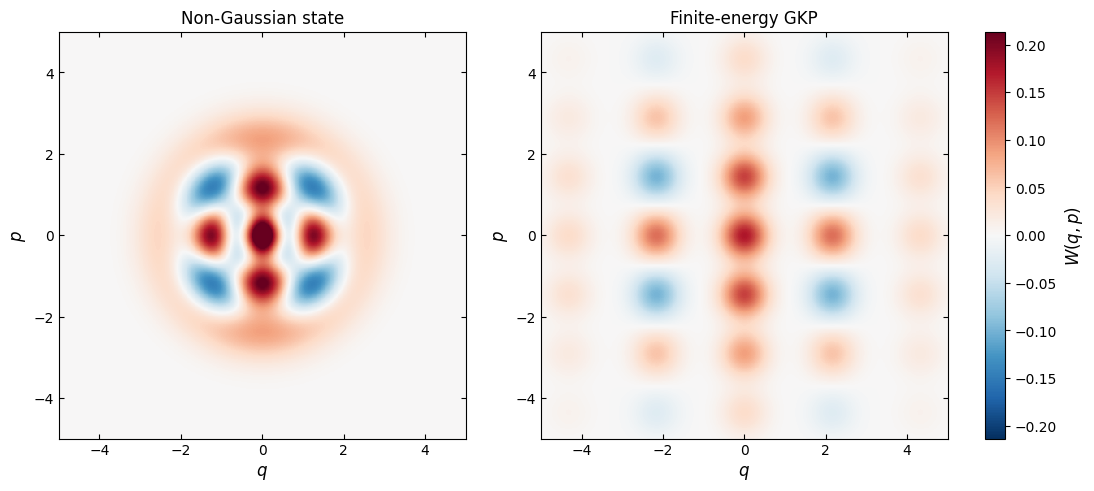

In [4]:
# Squeezing gate
r_GKP = 0.2
S_GKP = One_Mode_Squeeze(r = r_GKP)

# Generate GKP State resempling Non-Gaussian state
rect_GKP = GKPState.computational_GKP(0) \
            .apply_gaussian_gate(S_GKP)

delta = 0.4
Wigner_GKP = rect_GKP.wigner_finite_energy((q_min, q_max), (q_min, q_max), N_points, delta_x = delta)

compare_Wigners(
    Wigner1,
    Wigner_GKP,
    title1="Non-Gaussian state",
    title2="Finite-energy GKP",
    common_scale=True,
    shared_colorbar=True,
    percentile=99.7,
    dpi=400,
)

Need to implement search for optimal grid by varying grid squeezing $r_{GKP}$ and grid scaling $s$.